In [17]:
# Célula 1: Importações e Configurações Iniciais
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [18]:
# Célula 2: Carga e Inspeção Estrutural
df = pd.read_csv('../data/raw/bitext_intent.csv')

print("=== Shape do Dataset ===")
print(df.shape)
print("\n=== Colunas Disponíveis ===")
print(df.columns.tolist())
print("\n=== Tipos de Dados (dtypes) ===")
print(df.dtypes)
print("\n=== Valores Ausentes (Nulos) ===")
print(df.isnull().sum())

=== Shape do Dataset ===
(26872, 5)

=== Colunas Disponíveis ===
['flags', 'instruction', 'category', 'intent', 'response']

=== Tipos de Dados (dtypes) ===
flags          str
instruction    str
category       str
intent         str
response       str
dtype: object

=== Valores Ausentes (Nulos) ===
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64


In [19]:
# Célula 3: Engenharia de Recursos Vetorizada (Feature Engineering)
TEXT_COL = 'instruction'

df['char_count'] = df[TEXT_COL].str.len()
df['word_count'] = df[TEXT_COL].str.split().str.len()

print("\n=== Estatísticas Descritivas (describe) ===")
print(df[['char_count', 'word_count']].describe())


=== Estatísticas Descritivas (describe) ===
         char_count    word_count
count  26872.000000  26872.000000
mean      46.889513      8.690979
std       10.897578      2.605004
min        6.000000      1.000000
25%       40.000000      7.000000
50%       48.000000      9.000000
75%       55.000000     11.000000
max       92.000000     16.000000


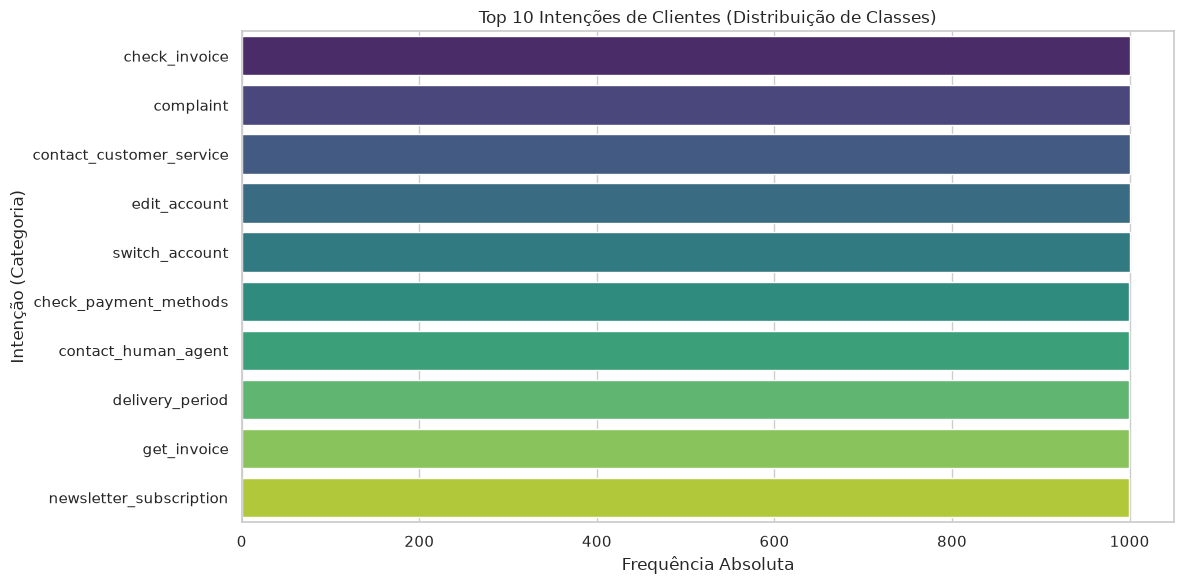

In [20]:
# Célula 4: Visualização 1 - Distribuição de Categorias (Gráfico de Barras)
plt.figure(figsize=(12, 6))
top_intents = df['intent'].value_counts().head(10)

sns.barplot(
    y=top_intents.index, x=top_intents.values,
    hue=top_intents.index, palette="viridis", legend=False
)
plt.title("Top 10 Intenções de Clientes (Distribuição de Classes)")
plt.xlabel("Frequência Absoluta")
plt.ylabel("Intenção (Categoria)")
plt.tight_layout()
plt.show()

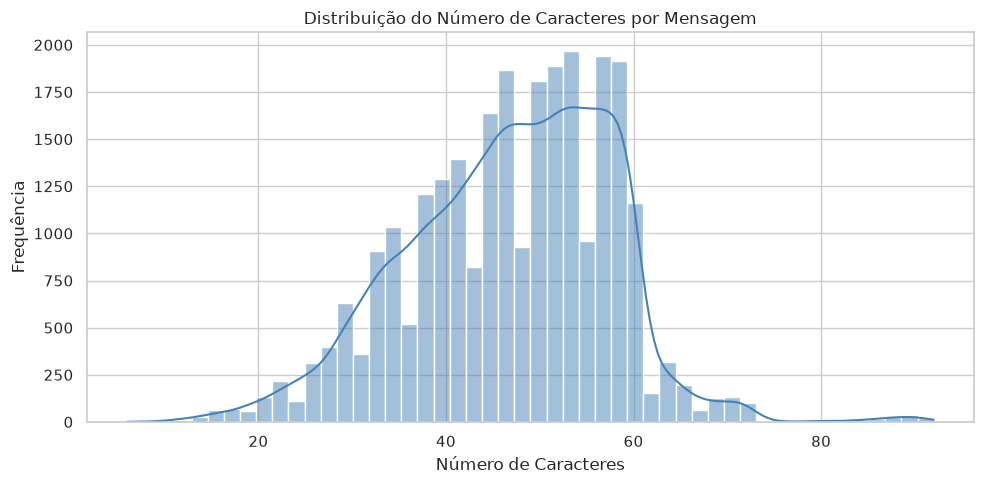

In [21]:
# Célula 5: Visualização 2 - Distribuição do Tamanho das Mensagens (Histograma)
plt.figure(figsize=(10, 5))
sns.histplot(df['char_count'], bins=50, kde=True, color='steelblue')
plt.title("Distribuição do Número de Caracteres por Mensagem")
plt.xlabel("Número de Caracteres")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

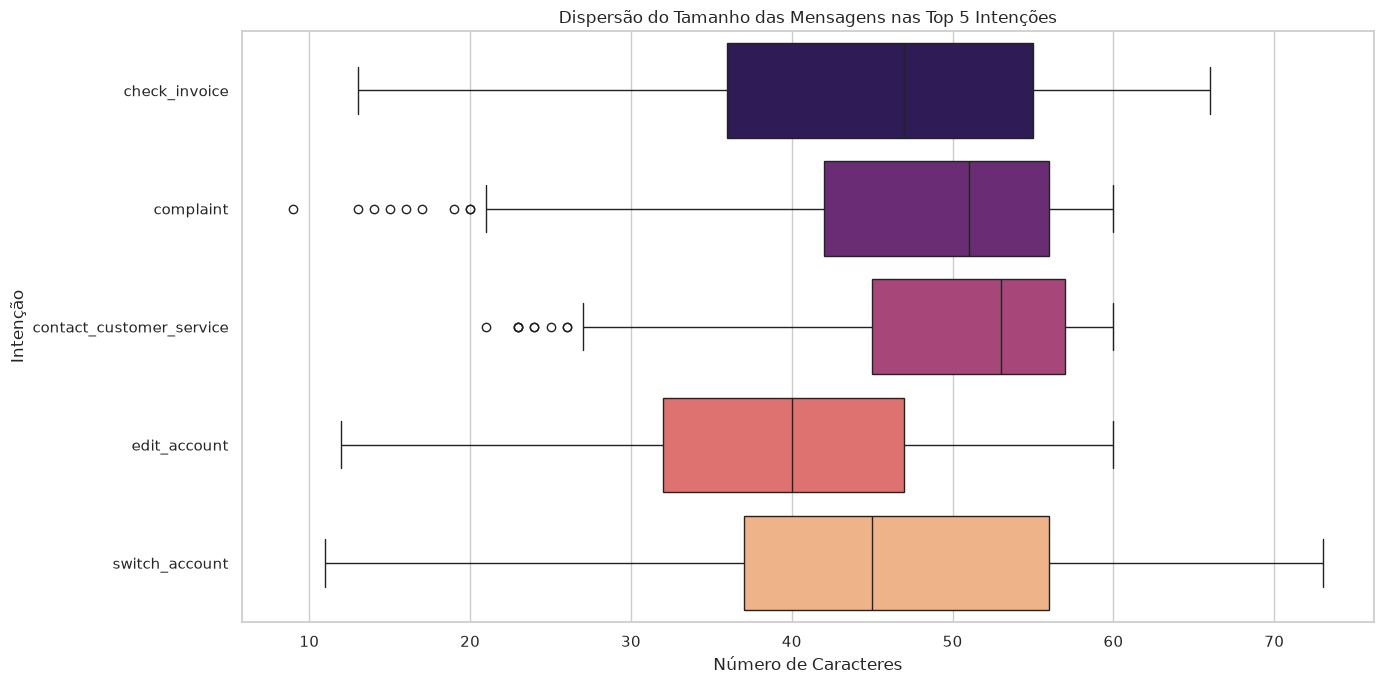

In [22]:
# Célula 6: Visualização 3 - Relação Intenção vs. Tamanho (Boxplot)
plt.figure(figsize=(14, 7))

top_5_intents = df['intent'].value_counts().head(5).index
df_filtered = df[df['intent'].isin(top_5_intents)].copy()

sns.boxplot(
    data=df_filtered, y='intent', x='char_count',
    order=top_5_intents,  # mantém a mesma ordem de frequência do gráfico anterior
    hue='intent', palette="magma", legend=False
)
plt.title("Dispersão do Tamanho das Mensagens nas Top 5 Intenções")
plt.xlabel("Número de Caracteres")
plt.ylabel("Intenção")
plt.tight_layout()
plt.show()

### 🧠 Hipóteses Comportamentais e Arquiteturais (E-ComShield)

Baseado na visualização estatística do dataset, formulamos três hipóteses críticas para o pipeline preditivo e de segurança:

1. **Urgência e Objetividade em Reclamações (Comportamental):**
   O Boxplot revela que as intenções `contact_customer_service` e `complaint` (as mais frequentes) concentram uma quantidade significativa de *outliers* inferiores. Isso sugere que clientes frustrados ou necessitados de contato humano tendem a enviar mensagens extremamente curtas e diretas (abaixo de 20 caracteres). O agente de IA precisará inferir intenções complexas a partir de poucas palavras nesses cenários.

2. **Complexidade Transacional (Comportamental):**
   A intenção `switch_account` apresenta a maior dispersão (IQR amplo) e a cauda superior mais longa (atingindo acima de 70 caracteres no limite superior do bigode). Isso indica que transações de mudança de conta exigem a passagem de parâmetros e contextos mais densos por parte do usuário, contrastando com intenções operacionais simples como `edit_account`, cuja mediana situa-se abaixo de 40 caracteres.

3. **Blindagem Arquitetural baseada na Distribuição (Segurança/Operacional):**
   A análise descritiva demonstra que 100% das mensagens operam dentro de um limite estrito: média de ~47 caracteres e valor máximo absoluto de 92 caracteres. Isso comprova a hipótese de que podemos limitar o `PredictRequest` (modelo Pydantic da API) a um `max_length=100`. Qualquer requisição excedendo esse limite constitui tráfego anômalo (potencial ataque DoS ou injeção de prompt), devendo ser bloqueada na camada HTTP antes de atingir o modelo preditivo.